In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
data = np.load(r'burgers.npz')
print(data.files)

['u_ref', 'dudt_ref', 'u_coarse']


In [3]:
nu = 0.0005 # viscosity
x_start = 0.0 # domain start
x_final = 1.0 # domain end
x_range = x_final - x_start # domain range
t_final = 0.5 # simulation end time
num_fine_grid = 4096 # number of fine grid points
num_coarse_grid = 64 # number of coarse grid points
snap_timestep = 2**(-7) # snapshot interval
num_snapshots = 64 # number of additional snapshots
num_trajectories = 128 # total trajectories generated

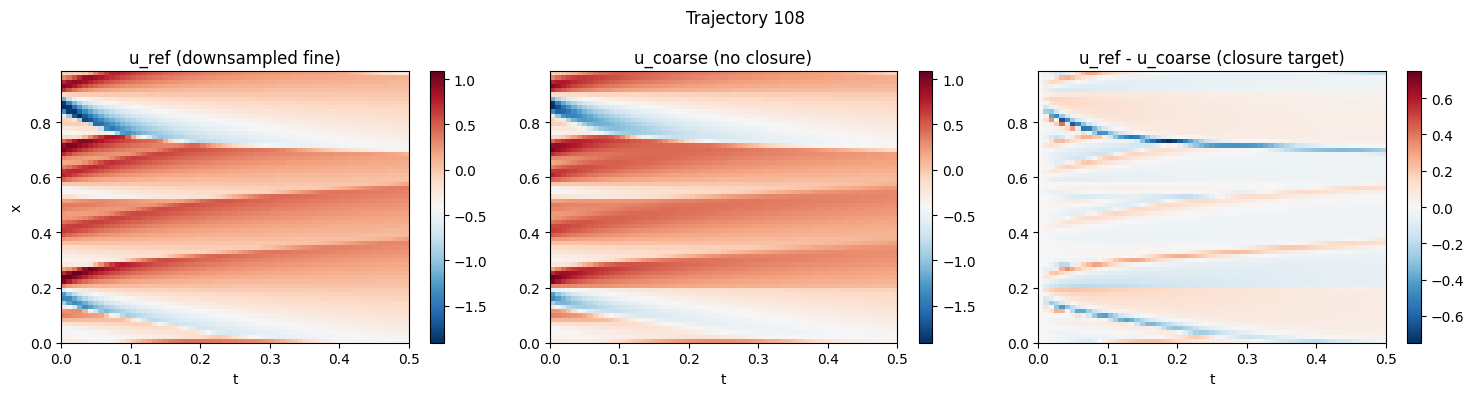

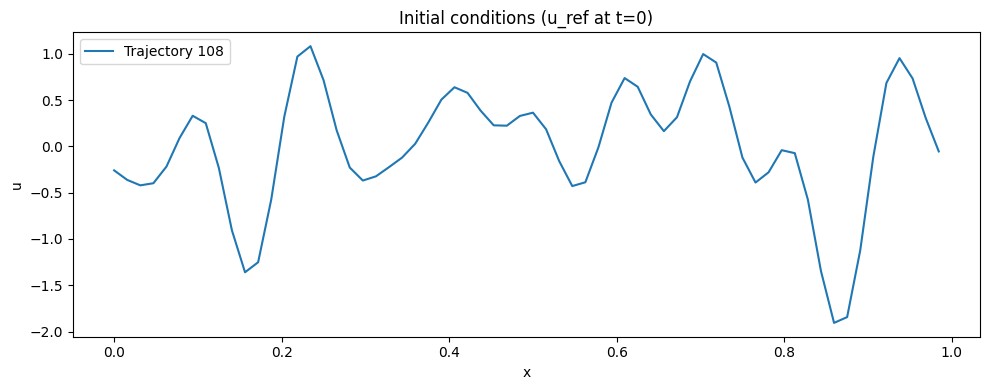

In [4]:
def visualize_trajectories(data, num_to_show=3, seed=0):
    """
    Visualize a few trajectories from the saved dataset.
    Shows u_ref, u_coarse, and their difference for each trajectory.
    """
    u_ref    = data['u_ref']   # (128, 65, 64)
    dudt_ref = data['dudt_ref']   # (128, 65, 64)
    u_coarse = data['u_coarse']   # (128, 65, 64)

    rng = np.random.default_rng(seed)
    indices = rng.choice(len(u_ref), num_to_show, replace=False)

    t = np.arange(u_ref.shape[1]) * snap_timestep
    x = np.linspace(x_start, x_final, num_coarse_grid, endpoint=False)

    for idx in indices:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Trajectory {idx}', fontsize=12)

        # Shared color scale across u_ref and u_coarse
        vmin = min(u_ref[idx].min(), u_coarse[idx].min())
        vmax = max(u_ref[idx].max(), u_coarse[idx].max())

        # u_ref: downsampled fine solution (the "truth")
        im0 = axes[0].imshow(
            u_ref[idx].T, aspect='auto', origin='lower',
            extent=[t[0], t[-1], x[0], x[-1]],
            vmin=vmin, vmax=vmax, cmap='RdBu_r'
        )
        axes[0].set_title('u_ref (downsampled fine)')
        axes[0].set_xlabel('t'); axes[0].set_ylabel('x')
        plt.colorbar(im0, ax=axes[0])

        # u_coarse: coarse solve with no closure
        im1 = axes[1].imshow(
            u_coarse[idx].T, aspect='auto', origin='lower',
            extent=[t[0], t[-1], x[0], x[-1]],
            vmin=vmin, vmax=vmax, cmap='RdBu_r'
        )
        axes[1].set_title('u_coarse (no closure)')
        axes[1].set_xlabel('t')
        plt.colorbar(im1, ax=axes[1])

        # Difference: what the closure model needs to correct
        diff = u_ref[idx] - u_coarse[idx]
        vmax_diff = np.max(np.abs(diff))
        im2 = axes[2].imshow(
            diff.T, aspect='auto', origin='lower',
            extent=[t[0], t[-1], x[0], x[-1]],
            vmin=-vmax_diff, vmax=vmax_diff, cmap='RdBu_r'
        )
        axes[2].set_title('u_ref - u_coarse (closure target)')
        axes[2].set_xlabel('t')
        plt.colorbar(im2, ax=axes[2])

        plt.tight_layout()
        plt.savefig(f'trajectory_{idx}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Also plot initial conditions across all trajectories
    fig, ax = plt.subplots(figsize=(10, 4))
    for idx in indices:
        ax.plot(x, u_ref[idx, 0, :], label=f'Trajectory {idx}')
    ax.set_title('Initial conditions (u_ref at t=0)')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend()
    plt.tight_layout()
    plt.savefig('initial_conditions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_trajectories(data, num_to_show=1)

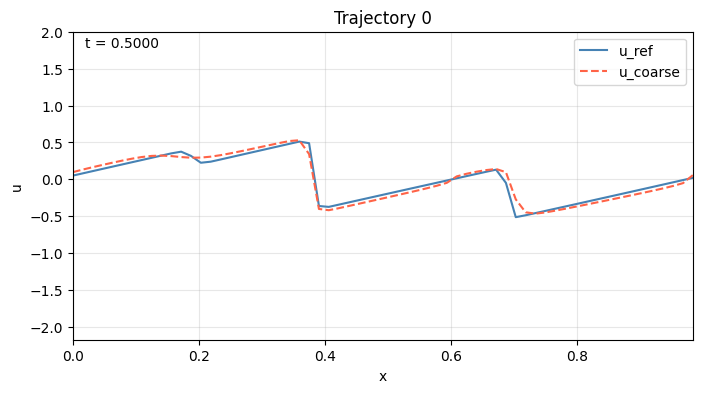

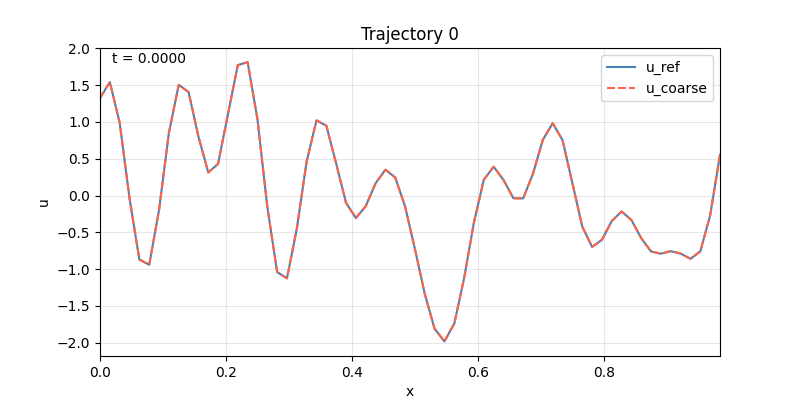

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


def animate_trajectory(data, traj_idx=0):
    """
    Animate a single trajectory evolving through time,
    showing u_ref and u_coarse side by side.
    """
    u_ref    = data['u_ref']   # (128, 65, 64)
    dudt_ref = data['dudt_ref']   # (128, 65, 64)
    u_coarse = data['u_coarse']   # (128, 65, 64)

    u_ref_traj    = u_ref[traj_idx]      # (65, 64)
    u_coarse_traj = u_coarse[traj_idx]   # (65, 64)

    t = np.arange(u_ref_traj.shape[0]) * snap_timestep
    x = np.linspace(x_start, x_final, num_coarse_grid, endpoint=False)

    # Fixed y-axis limits across all frames
    ymin = min(u_ref_traj.min(), u_coarse_traj.min()) * 1.1
    ymax = max(u_ref_traj.max(), u_coarse_traj.max()) * 1.1

    fig, ax = plt.subplots(figsize=(8, 4))

    line_ref,    = ax.plot(x, u_ref_traj[0],    label='u_ref',    color='steelblue')
    line_coarse, = ax.plot(x, u_coarse_traj[0], label='u_coarse', color='tomato', linestyle='--')
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.set_title(f'Trajectory {traj_idx}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    def update(frame):
        line_ref.set_ydata(u_ref_traj[frame])
        line_coarse.set_ydata(u_coarse_traj[frame])
        time_text.set_text(f't = {t[frame]:.4f}')
        return line_ref, line_coarse, time_text

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(t),
        interval=100,    # ms between frames
        blit=True,
    )

    ani.save(f'trajectory_{traj_idx}.gif', writer='pillow', fps=10)
    plt.show()
    return ani

ani = animate_trajectory(data, traj_idx=0)
from IPython.display import Image

ani.save('trajectory.gif', writer='pillow', fps=10)
Image('trajectory.gif')

Train snapshots: 6240
Test snapshots:  2080


  1%|          | 100/10000 [00:56<4:04:53,  1.48s/it]

Epoch 100/10000  loss: 7.813612


  2%|▏         | 200/10000 [01:26<47:22,  3.45it/s]  

Epoch 200/10000  loss: 6.799460


...

Epoch 9800/10000  loss: 6.061421


 99%|█████████▉| 9900/10000 [55:43<00:25,  3.97it/s]

Epoch 9900/10000  loss: 6.069921


100%|██████████| 10000/10000 [56:09<00:00,  2.97it/s]


Epoch 10000/10000  loss: 6.080327
cuda:0


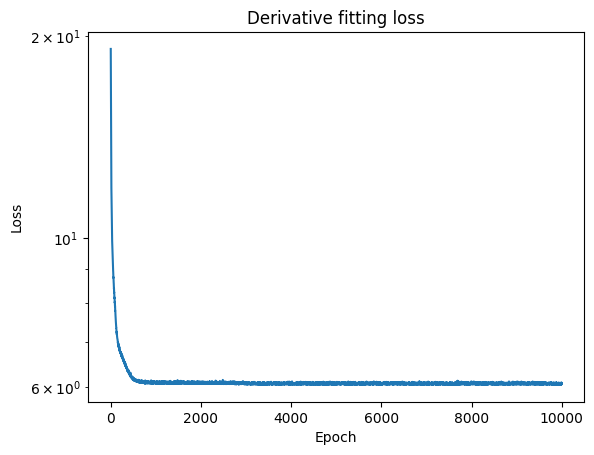

In [10]:
delta_x_coarse = x_range / num_coarse_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BurgersDataset(Dataset):

    def __init__(self, u_ref, dudt_ref):
        # Flatten (num_traj, nt, nx) -> (num_traj*nt, nx)
        nx = u_ref.shape[-1]
        self.u    = torch.tensor(u_ref.reshape(-1, nx), dtype=torch.float32)
        self.dudt = torch.tensor(dudt_ref.reshape(-1, nx), dtype=torch.float32)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.dudt[idx]

def burgers_coarse(u):
    """
    Coarse grid Burgers RHS (no closure).
    u shape: (batch, nx)
    """
    u_minus = torch.roll(u,  1, dims=1)
    u_plus  = torch.roll(u, -1, dims=1)

    term1 = (nu / delta_x_coarse**2) * (u_minus - 2*u + u_plus)

    alpha_plus  = 0.25 * torch.abs(u + u_plus)  - (1/12) * (u_plus  - u)
    alpha_minus = 0.25 * torch.abs(u_minus + u) - (1/12) * (u - u_minus)

    f_plus  = (1/6)*(u**2 + u*u_plus  + u_plus**2)  - alpha_plus  * (u_plus  - u)
    f_minus = (1/6)*(u_minus**2 + u_minus*u + u**2) - alpha_minus * (u - u_minus)

    return term1 - (f_plus - f_minus) / delta_x_coarse

class ClosureCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(2, 2, kernel_size=9, padding=4, padding_mode='circular', bias=True)
        self.conv2 = nn.Conv1d(2, 1, kernel_size=9, padding=4, padding_mode='circular', bias=True)

    def forward(self, u):
        # u shape: (batch, nx)
        # Add channel dimension and square channel
        u_input = torch.stack([u, u**2], dim=1)   # (batch, 2, nx)
        x = torch.tanh(self.conv1(u_input))        # (batch, 2, nx)
        x = self.conv2(x).squeeze(1)         # (batch, nx)
        return torch.roll(x, -1, dims=1) - x

class DerivativeFitter:

    def __init__(self, model, lr=1e-3):
        self.model = model.to(device)
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.loss_mse = nn.MSELoss()

    def loss(self, u_batch, dudt_batch):
        dudt_pred = burgers_coarse(u_batch) + self.model(u_batch)
        return self.loss_mse(dudt_pred, dudt_batch)

    def train(self, train_loader, n_epochs):

        losses = []

        for epoch in tqdm(range(n_epochs)):
            epoch_losses = []

            for u_batch, dudt_batch in train_loader:
                u_batch = u_batch.to(device)
                dudt_batch = dudt_batch.to(device)

                self.optimizer.zero_grad()
                loss = self.loss(u_batch, dudt_batch)
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            epoch_loss = np.mean(epoch_losses)
            losses.append(epoch_loss)

            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}  loss: {epoch_loss:.6f}")

        return losses


# Load data
data           = np.load("burgers.npz")
u_ref          = data['u_ref']     # (128, 65, 64)
dudt_ref       = data['dudt_ref']  # (128, 65, 64)

u_ref_train    = u_ref[:96]
u_ref_test     = u_ref[96:]
dudt_ref_train = dudt_ref[:96]
dudt_ref_test  = dudt_ref[96:]

# Create datasets and dataloaders
train_dataset = BurgersDataset(u_ref_train, dudt_ref_train)
test_dataset  = BurgersDataset(u_ref_test,  dudt_ref_test)

train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train snapshots: {len(train_dataset)}")
print(f"Test snapshots:  {len(test_dataset)}") 

# Train
model  = ClosureCNN()
fitter = DerivativeFitter(model, lr=0.001)
losses = fitter.train(train_loader, n_epochs=10000)

print(next(model.parameters()).device)

# Plot loss
plt.figure()
plt.plot(losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Derivative fitting loss')
plt.savefig('derivative_fitting_loss.png')
plt.show()

# Save
torch.save(model.state_dict(), 'closure_cnn_derivative_full.pt')

In [11]:
np.save('losses.npy', np.array(losses))

In [12]:
losses = np.load('losses.npy')
rmses = np.sqrt(losses)

In [15]:
rmses

array([4.37359487, 4.28582331, 4.16332196, ..., 2.46391562, 2.46898888,
       2.465832  ], shape=(10000,))

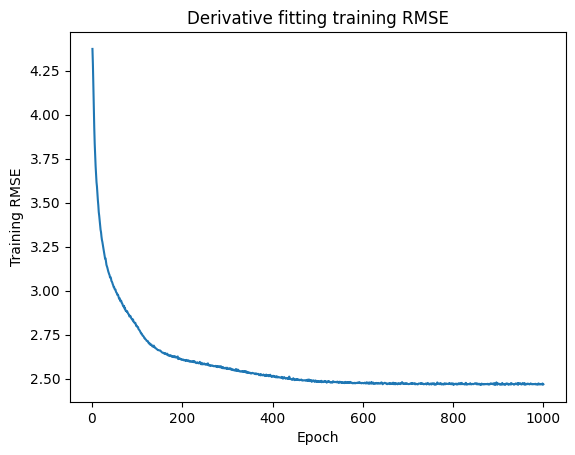

In [31]:
plt.plot(list(range(1,1001)), rmses[:1000])
plt.xlabel('Epoch')
plt.ylabel('Training RMSE')
plt.title('Derivative fitting training RMSE')
plt.savefig('derivative_fitting_rmse.png')
plt.show()

In [27]:
u_coarse = data['u_coarse']

# Test split
u_coarse_test = u_coarse[96:]

# RMSE across all test snapshots and all spatial points
rmse_coarse = np.sqrt(((u_coarse_test - u_ref_test)**2).mean())
print(f"Coarse ODE (no closure) test RMSE:  {rmse_coarse:.4f}")
print(f"Paper RMSE: 0.104")

Coarse ODE (no closure) test RMSE:  0.1036
Paper RMSE: 0.104


In [26]:
from scipy.integrate import solve_ivp

# Load the trained model
model = ClosureCNN()
model.load_state_dict(torch.load('closure_cnn_derivative_full.pt'))
model.to(device)
model.eval()

def closure_rhs(t, u_np):
    """
    scipy-compatible RHS: f_coarse(u) + NN(u).
    u_np shape: (nx,) numpy. Returns (nx,) numpy.
    """
    u_torch = torch.tensor(u_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        f_c   = burgers_coarse(u_torch)           # (1, nx)
        nn_out = model(u_torch)                   # (1, nx)
        dudt  = (f_c + nn_out).squeeze(0).cpu().numpy()
    return dudt


def rollout_test_trajectories(u_ref_test):
    """
    For each test initial condition, roll out the closure model and
    return the predicted trajectory.
    """
    t_eval = np.arange(num_snapshots + 1) * snap_timestep
    predictions = np.zeros_like(u_ref_test)

    for i in tqdm(range(len(u_ref_test))):
        u0 = u_ref_test[i, 0]                     # (nx,) — initial condition
        sol = solve_ivp(
            closure_rhs,
            t_span=(0.0, t_final),
            y0=u0,
            method='RK45',
            t_eval=t_eval,
            rtol=1e-6,
            atol=1e-6,
        )
        predictions[i] = sol.y.T                  # (nt, nx)

    return predictions

u_derivfit_test = rollout_test_trajectories(u_ref_test)

rmse_derivfit = np.sqrt(((u_derivfit_test - u_ref_test)**2).mean())
print(f"Derivative fitting test RMSE: {rmse_derivfit:.4f}")
print(f"Paper RMSE: 2.67")

  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [01:15<00:00,  2.34s/it]

Derivative fitting test RMSE: 3.8156
Paper RMSE: 2.67
